# Fintech Retention Analysis

### 1. Retention & engagement diagnosis
- **H1**: Purchase **recency and frequency** in the observation window are the strongest predictors of whether a card churns in the outcome window — i.e., retention is driven more by *habit formation* than by transaction value.
- **H2**: Cards that go quiet for 30+ days have a materially lower probability of reactivating than cards with a shorter gap — establishing a "critical inactivity threshold" (this is the kind of number a lifecycle/marketing team would use to trigger a win-back campaign).
- **H3**: New cohorts (recent `first_active_month`) show a steeper early drop-off than older cohorts — an "onboarding/activation risk" story, directly relevant to a growth team worried about new-user retention curves. --> Tested on Fintech Cohort Analysis Notebook

- Define churn as 90+ days of inactivity per card_id

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm,skew
from scipy import stats
import datetime as dt
%matplotlib inline

In [4]:
!pip list

Package                           Version
--------------------------------- ------------------
absl-py                           2.3.1
aext-assistant                    4.0.15
aext-assistant-server             4.0.15
aext-core                         4.0.15
aext-core-server                  4.0.15
aext-panels                       4.0.15
aext-panels-server                4.0.15
aext-share-notebook               4.0.15
aext-share-notebook-server        4.0.15
aext-shared                       4.0.15
agate                             1.9.1
aiobotocore                       2.12.3
aiohttp                           3.9.5
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.16
altair                            5.0.1
anaconda-anon-usage               0.4.4
anaconda-catalogs                 0.2.0
anaconda-client                   1.12.3
anaconda-cloud-auth               0.5.1
anaconda-navigator                2.6.0
anaconda-proj

In [5]:
new = pd.read_csv('new_merchant_transactions.csv')
historical = pd.read_csv('historical_transactions.csv')
merchants = pd.read_csv('merchants.csv')

In [6]:
new.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_415bb3a509,107,N,1,B,307,M_ID_b0c793002c,1,-0.557574,2018-03-11 14:57:36,1.0,9,19
1,Y,C_ID_415bb3a509,140,N,1,B,307,M_ID_88920c89e8,1,-0.569580,2018-03-19 18:53:37,1.0,9,19
2,Y,C_ID_415bb3a509,330,N,1,B,507,M_ID_ad5237ef6b,2,-0.551037,2018-04-26 14:08:44,1.0,9,14
3,Y,C_ID_415bb3a509,-1,Y,1,B,661,M_ID_9e84cda3b1,1,-0.671925,2018-03-07 09:43:21,NaN,-1,8
4,Y,C_ID_ef55cf8d4b,-1,Y,1,B,166,M_ID_3c86fa3831,1,-0.659904,2018-03-22 21:07:53,NaN,-1,29


In [7]:
print(f"Earliest date:", new['purchase_date'].min())
print(f"Latest date:", new['purchase_date'].max())

Earliest date: 2017-03-01 03:24:51
Latest date: 2018-04-30 23:59:59


In [8]:
historical.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37


In [9]:
print(f"Earliest date:", historical['purchase_date'].min())
print(f"Latest date:", historical['purchase_date'].max())

Earliest date: 2017-01-01 00:00:08
Latest date: 2018-02-28 23:59:51


In [10]:
new['merchant_id'].value_counts()

merchant_id
M_ID_00a6ca8a8a    23018
M_ID_cd2c0b07e9    19118
M_ID_9139332ccc    14220
M_ID_50f575c681    13778
M_ID_725a60d404     7029
                   ...  
M_ID_5ad92e0a51        1
M_ID_755372244e        1
M_ID_4b750a82b0        1
M_ID_28f7e90c9b        1
M_ID_670cdecb69        1
Name: count, Length: 226129, dtype: int64

In [11]:
historical['merchant_id'].value_counts()

merchant_id
M_ID_00a6ca8a8a    1115097
M_ID_e5374dabc0     428619
M_ID_9139332ccc     361385
M_ID_50f575c681     183894
M_ID_fc7d7969c3     177040
                    ...   
M_ID_e5f2c7e685          1
M_ID_437a5a14a9          1
M_ID_b62fd56d1c          1
M_ID_6a903de20c          1
M_ID_cc4d12f06a          1
Name: count, Length: 326311, dtype: int64

In [12]:
# check the merchant_id in new but not in historical
# ~ means NOT
new_merchants = new.loc[
    ~new["merchant_id"].isin(historical["merchant_id"]),
    "merchant_id"
].unique()

In [13]:
print(new_merchants)
print(f"merchant_id in historical:", len(historical["merchant_id"]))
print(f"merchant_id in new:", len(new["merchant_id"]))
print(f"merchant_id not in historical but in new:", len(new_merchants))

['M_ID_a1183a4e5e' 'M_ID_3b3ec0f162' 'M_ID_df85bd38ef' ...
 'M_ID_d722baf580' 'M_ID_79edabf769' 'M_ID_4247d8f9d5']
merchant_id in historical: 29112361
merchant_id in new: 1963031
merchant_id not in historical but in new: 8322


In [14]:
# Concatenate two datasets
transactions = pd.concat(
    [historical, new],
    ignore_index=True
)

In [15]:
transactions[:5]

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37


In [16]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31075392 entries, 0 to 31075391
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   authorized_flag       object 
 1   card_id               object 
 2   city_id               int64  
 3   category_1            object 
 4   installments          int64  
 5   category_3            object 
 6   merchant_category_id  int64  
 7   merchant_id           object 
 8   month_lag             int64  
 9   purchase_amount       float64
 10  purchase_date         object 
 11  category_2            float64
 12  state_id              int64  
 13  subsector_id          int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 3.2+ GB


In [17]:
# change purchase_date to datetime
# add year and date
to_year = pd.to_datetime(transactions['purchase_date'])
transactions.loc[:,'year'] = to_year.dt.year
transactions.loc[:,'date'] = to_year.dt.date
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31075392 entries, 0 to 31075391
Data columns (total 16 columns):
 #   Column                Dtype  
---  ------                -----  
 0   authorized_flag       object 
 1   card_id               object 
 2   city_id               int64  
 3   category_1            object 
 4   installments          int64  
 5   category_3            object 
 6   merchant_category_id  int64  
 7   merchant_id           object 
 8   month_lag             int64  
 9   purchase_amount       float64
 10  purchase_date         object 
 11  category_2            float64
 12  state_id              int64  
 13  subsector_id          int64  
 14  year                  int32  
 15  date                  object 
dtypes: float64(2), int32(1), int64(6), object(7)
memory usage: 3.6+ GB


In [18]:
print(f"Earliest date:", transactions['purchase_date'].min())
print(f"Latest date:",transactions['purchase_date'].max())

Earliest date: 2017-01-01 00:00:08
Latest date: 2018-04-30 23:59:59


## H1: Recency and frequency predict churn
- H1: Purchase recency and frequency in the observation window are the strongest predictors of whether a card churns in the outcome window — i.e., retention is driven more by habit formation than by transaction value.

- In this project, I will define **"Churned"** as:
- **A card's last transaction occurs at least 90 days before the end of the observation period, with no subsequent transaction.**

#### Create a churn flag
**The Churn s defined here as follows:**
Observed churn: A card is classified as churned if its last observed transaction occurred at least 90 days before the end of the transaction observation period.

In [21]:
# 1. Convert purchase_date
transactions['purchase_date'] = pd.to_datetime(transactions['purchase_date'])
transactions['purchase_date'].min(), transactions['purchase_date'].max()

(Timestamp('2017-01-01 00:00:08'), Timestamp('2018-04-30 23:59:59'))

In [22]:
# 2. Define the observation end date
observation_end = transactions['purchase_date'].max()
print(f"Observation end date:", observation_end)

# Calculate the 90-day cutoff (=Churned)
churn_cutoff = observation_end - pd.Timedelta(days=90)
print(f"90-day cutoff (Churned):", churn_cutoff)

Observation end date: 2018-04-30 23:59:59
90-day cutoff (Churned): 2018-01-30 23:59:59


In [23]:
# 3. Find the last transaction for each card
last_transaction = (
    transactions.groupby('card_id')['purchase_date']
      .max()
      .reset_index()
)

In [24]:
# rename the columns
last_transaction = last_transaction.rename(
    columns={'purchase_date': 'last_purchase_date'}
)
last_transaction.head()

,card_id,last_purchase_date
0,C_ID_00007093c1,2018-04-09 16:23:59
1,C_ID_0001238066,2018-04-30 19:57:30
2,C_ID_0001506ef0,2018-03-22 09:14:30
3,C_ID_0001793786,2017-12-31 17:35:56
4,C_ID_000183fdda,2018-04-30 14:59:53


In [25]:
# 4. Calculate days since last transaction
# Make the churn definition more transparent
last_transaction['days_since_last_purchase'] = (
    observation_end
    - last_transaction['last_purchase_date']
).dt.days
last_transaction.head()

,card_id,last_purchase_date,days_since_last_purchase
0,C_ID_00007093c1,2018-04-09 16:23:59,21
1,C_ID_0001238066,2018-04-30 19:57:30,0
2,C_ID_0001506ef0,2018-03-22 09:14:30,39
3,C_ID_0001793786,2017-12-31 17:35:56,120
4,C_ID_000183fdda,2018-04-30 14:59:53,0


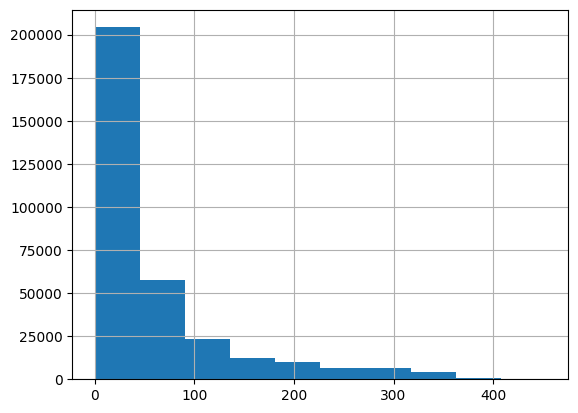

In [26]:
# plot the frequency of days since last purchase
last_transaction['days_since_last_purchase'].hist()
plt.show()

In [27]:
# merge churn flags
transactions = pd.merge(transactions, last_transaction, on='card_id', how='outer')
transactions.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id,year,date,last_purchase_date,days_since_last_purchase
0,Y,C_ID_00007093c1,244,N,1,B,307,M_ID_9400cf2342,-4,-0.530526,2017-10-02 19:09:42,3.0,2,19,2017,2017-10-02,2018-04-09 16:23:59,21
1,Y,C_ID_00007093c1,244,N,1,B,705,M_ID_a33355a1b7,-12,-0.467415,2017-02-14 15:47:45,3.0,2,33,2017,2017-02-14,2018-04-09 16:23:59,21
2,N,C_ID_00007093c1,244,N,1,B,108,M_ID_15446e939c,-9,0.307953,2017-05-18 16:52:22,3.0,2,34,2017,2017-05-18,2018-04-09 16:23:59,21
3,Y,C_ID_00007093c1,76,N,3,C,45,M_ID_84e60960a3,-6,-0.559076,2017-08-05 11:27:35,3.0,2,18,2017,2017-08-05,2018-04-09 16:23:59,21
4,Y,C_ID_00007093c1,-1,Y,1,B,755,M_ID_57df19bf28,-7,-0.709342,2017-07-03 15:43:57,NaN,-1,8,2017,2017-07-03,2018-04-09 16:23:59,21


In [28]:
# 5. Create the churn flag
last_transaction['churned_90d'] = (
    last_transaction['days_since_last_purchase'] >= 90
)
last_transaction['churned_90d'].value_counts()

churned_90d
False    260822
True      64718
Name: count, dtype: int64

### Create RFM Variables

In [30]:
# Recency 
#Recency dataset
most_recent = transactions['date'].max()+dt.timedelta(days=1)
print(most_recent)

2018-05-01


In [31]:
Recency_filtered = transactions.groupby('card_id').date.agg(lambda x:(most_recent - x.max())).reset_index(name='recency')
print(Recency_filtered)

                card_id  recency
0       C_ID_00007093c1  22 days
1       C_ID_0001238066   1 days
2       C_ID_0001506ef0  40 days
3       C_ID_0001793786 121 days
4       C_ID_000183fdda   1 days
...                 ...      ...
325535  C_ID_ffff1d9928  11 days
325536  C_ID_ffff579d3a  41 days
325537  C_ID_ffff756266  21 days
325538  C_ID_ffff828181   2 days
325539  C_ID_fffffd5772  35 days

[325540 rows x 2 columns]


In [32]:
# Frequency
#Frequency dataset
Frequency_filtered = transactions.groupby('card_id').purchase_date.count().reset_index(name='frequency')
Frequency_filtered.head()

,card_id,frequency
0,C_ID_00007093c1,151
1,C_ID_0001238066,149
2,C_ID_0001506ef0,68
3,C_ID_0001793786,247
4,C_ID_000183fdda,155


In [33]:
# Monetary values


In [34]:
# merge Recency_filtered and Frequency_filtered to transactions dataset
transactions_rf = pd.merge(transactions, Frequency_filtered, on='card_id', how='outer')
transactions_rf = pd.merge(transactions_rf, Recency_filtered, on='card_id', how='outer')
# transactions = pd.merge(transactions, Monetary_filtered, on='card_id', how='outer')
transactions_rf.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id,year,date,last_purchase_date,days_since_last_purchase,frequency,recency
0,Y,C_ID_00007093c1,244,N,1,B,307,M_ID_9400cf2342,-4,-0.530526,2017-10-02 19:09:42,3.0,2,19,2017,2017-10-02,2018-04-09 16:23:59,21,151,22 days
1,Y,C_ID_00007093c1,244,N,1,B,705,M_ID_a33355a1b7,-12,-0.467415,2017-02-14 15:47:45,3.0,2,33,2017,2017-02-14,2018-04-09 16:23:59,21,151,22 days
2,N,C_ID_00007093c1,244,N,1,B,108,M_ID_15446e939c,-9,0.307953,2017-05-18 16:52:22,3.0,2,34,2017,2017-05-18,2018-04-09 16:23:59,21,151,22 days
3,Y,C_ID_00007093c1,76,N,3,C,45,M_ID_84e60960a3,-6,-0.559076,2017-08-05 11:27:35,3.0,2,18,2017,2017-08-05,2018-04-09 16:23:59,21,151,22 days
4,Y,C_ID_00007093c1,-1,Y,1,B,755,M_ID_57df19bf28,-7,-0.709342,2017-07-03 15:43:57,NaN,-1,8,2017,2017-07-03,2018-04-09 16:23:59,21,151,22 days


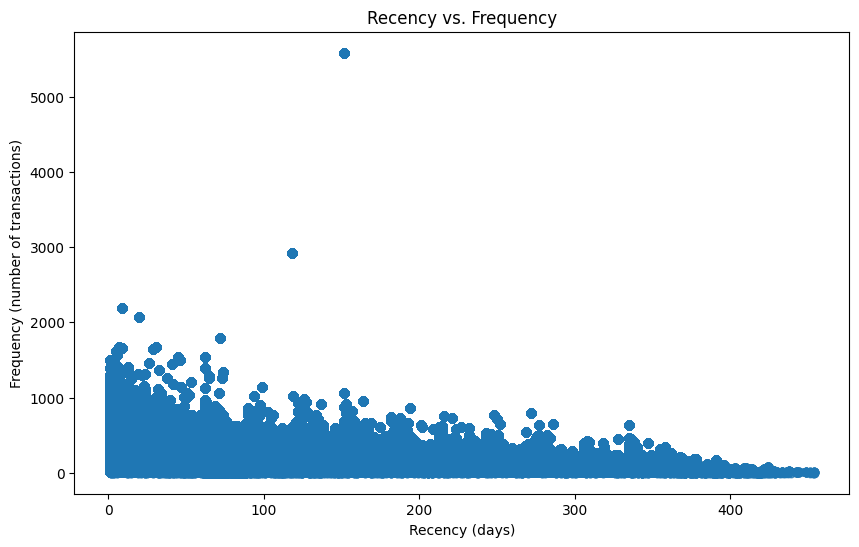

In [35]:
# Visualization
def f_and_r_scatter_plot(df):
    # convert recency to numeric
    df['recency_days'] = (
    df['recency']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(float)
    )
    # basic scatterplot
    plt.figure(figsize=(10, 6))

    plt.scatter(
        df['recency_days'],
        df['frequency'],
        alpha=0.5
    )

    plt.xlabel('Recency (days)')
    plt.ylabel('Frequency (number of transactions)')
    plt.title('Recency vs. Frequency')
    
    plt.show()

f_and_r_scatter_plot(transactions_rf)

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_5284/2429106668.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['recency_days'] = (


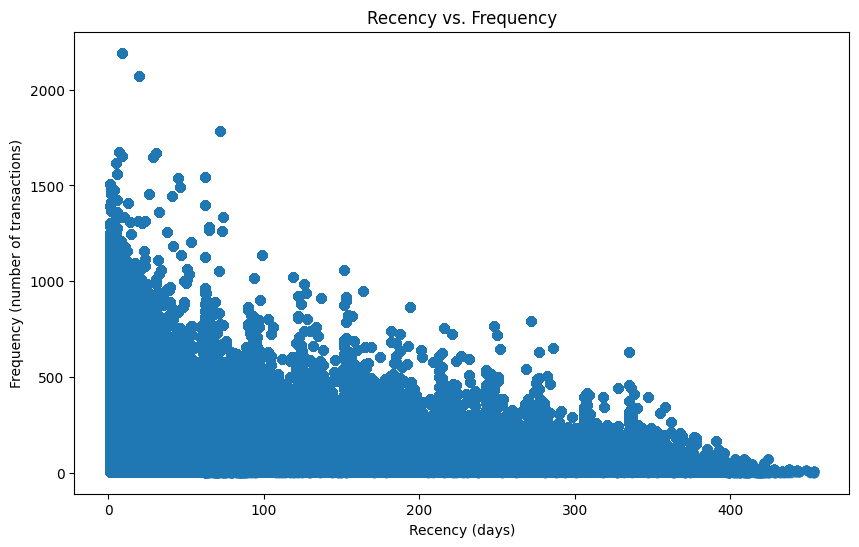

In [36]:
# There are two outliers in Frequency so will exclude them and visualize again
transactions_rf_ex_outlier = transactions_rf[transactions_rf['frequency'] < 2500]
f_and_r_scatter_plot(transactions_rf_ex_outlier)

In [37]:
#Assign RFM scores
#
recency_scores = range(5,0,-1)
frequency_scores = range(1,6)
# monetary_scores = range(1,6)

transactions_rf['r'] = pd.cut(transactions_rf['recency'], bins=5, labels = recency_scores)
transactions_rf['f'] = pd.cut(transactions_rf['frequency'], bins=5, labels = frequency_scores)
# rfm['m'] = pd.cut(rfm['monetary'], bins=5, labels = monetary_scores)

In [38]:
# merge churn flags
transactions_rf = pd.merge(transactions_rf, last_transaction, on='card_id', how='outer')
transactions_rf.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,...,last_purchase_date_x,days_since_last_purchase_x,frequency,recency,recency_days,r,f,last_purchase_date_y,days_since_last_purchase_y,churned_90d
0,Y,C_ID_00007093c1,244,N,1,B,307,M_ID_9400cf2342,-4,-0.530526,...,2018-04-09 16:23:59,21,151,22 days,22.0,5,1,2018-04-09 16:23:59,21,False
1,Y,C_ID_00007093c1,244,N,1,B,705,M_ID_a33355a1b7,-12,-0.467415,...,2018-04-09 16:23:59,21,151,22 days,22.0,5,1,2018-04-09 16:23:59,21,False
2,N,C_ID_00007093c1,244,N,1,B,108,M_ID_15446e939c,-9,0.307953,...,2018-04-09 16:23:59,21,151,22 days,22.0,5,1,2018-04-09 16:23:59,21,False
3,Y,C_ID_00007093c1,76,N,3,C,45,M_ID_84e60960a3,-6,-0.559076,...,2018-04-09 16:23:59,21,151,22 days,22.0,5,1,2018-04-09 16:23:59,21,False
4,Y,C_ID_00007093c1,-1,Y,1,B,755,M_ID_57df19bf28,-7,-0.709342,...,2018-04-09 16:23:59,21,151,22 days,22.0,5,1,2018-04-09 16:23:59,21,False


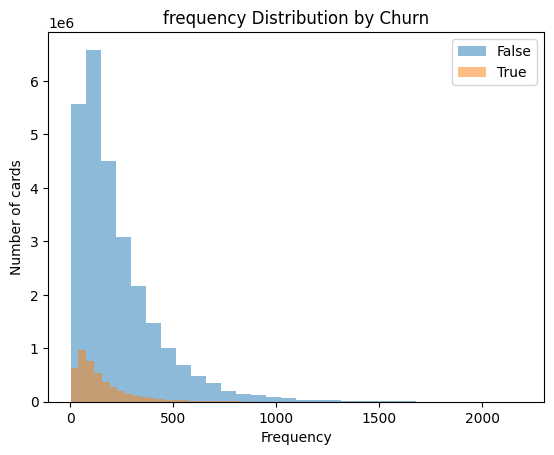

In [39]:
# Visualization
transactions_rf_ex_outlier= pd.merge(transactions_rf_ex_outlier, last_transaction, on='card_id', how='outer')
# Frequency vs Churn
groups = transactions_rf_ex_outlier["churned_90d"].unique()

for group in groups:
    plt.hist(
        transactions_rf_ex_outlier.loc[transactions_rf_ex_outlier["churned_90d"] == group, "frequency"],
        bins=30,
        alpha=0.5,
        label=group
    )

plt.xlabel("Frequency")
plt.ylabel("Number of cards")
plt.title("frequency Distribution by Churn")
plt.legend()
plt.show()

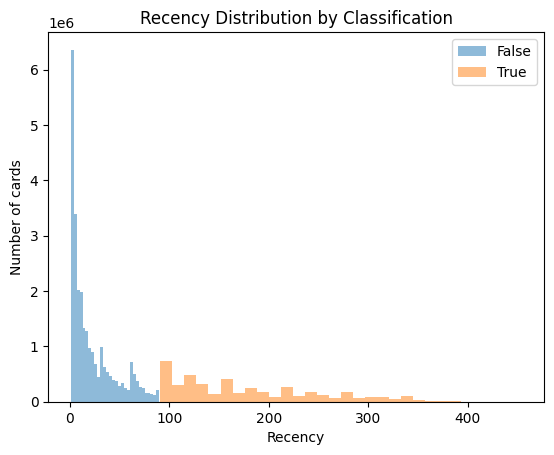

In [40]:
# Recency vs Churn
groups = transactions_rf_ex_outlier["churned_90d"].unique()

for group in groups:
    plt.hist(
        transactions_rf_ex_outlier.loc[transactions_rf_ex_outlier["churned_90d"] == group, "recency_days"],
        bins=30,
        alpha=0.5,
        label=group
    )

plt.xlabel("Recency")
plt.ylabel("Number of cards")
plt.title("Recency Distribution by Classification")
plt.legend()
plt.show()


In [41]:
# Define recency bins
bins = [0, 7, 14, 30, 60, 90, 120, 180, np.inf]

labels = [
    "0–7 days",
    "8–14 days",
    "15–30 days",
    "31–60 days",
    "61–90 days",
    "91–120 days",
    "121–180 days",
    "180+ days"
]

transactions_rf["recency_bin"] = pd.cut(
    transactions_rf["recency_days"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

transactions_rf["frequency_bin"] = pd.cut(
    transactions_rf["frequency"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [42]:
# use last_transaction to use card_id level datasets
# merge recency_days column from transactions_rf
recency_days = transactions_rf[["card_id", "recency_days", "frequency", "recency_bin", "frequency_bin"]]
last_transaction = pd.merge(last_transaction, recency_days, on='card_id', how='left')

In [43]:
last_transaction.head()

,card_id,last_purchase_date,days_since_last_purchase,churned_90d,recency_days,frequency,recency_bin,frequency_bin
0,C_ID_00007093c1,2018-04-09 16:23:59,21,False,22.0,151,15–30 days,121–180 days
1,C_ID_00007093c1,2018-04-09 16:23:59,21,False,22.0,151,15–30 days,121–180 days
2,C_ID_00007093c1,2018-04-09 16:23:59,21,False,22.0,151,15–30 days,121–180 days
3,C_ID_00007093c1,2018-04-09 16:23:59,21,False,22.0,151,15–30 days,121–180 days
4,C_ID_00007093c1,2018-04-09 16:23:59,21,False,22.0,151,15–30 days,121–180 days


In [154]:
# Define recency bins
bins = [0, 7, 14, 30, 60, 90, 120, 180, np.inf]

labels = [
    "0–7 days",
    "8–14 days",
    "15–30 days",
    "31–60 days",
    "61–90 days",
    "91–120 days",
    "121–180 days",
    "180+ days"
]

last_transaction["recency_bin"] = pd.cut(
    last_transaction["recency_days"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

bins_f = [0, 1, 2, 5, 10, 20, 50, np.inf]

labels_f = [
    "1",
    "2",
    "3–5",
    "6–10",
    "11–20",
    "21–50",
    "51+"
]

last_transaction["frequency_bin"] = pd.cut(
    last_transaction["frequency"],
    bins=bins_f,
    labels=labels_f,
    include_lowest=True
)

In [45]:
transactions_rf["recency_days"].describe().round(2)

count    31075392.00
mean           43.29
std            64.23
min             1.00
25%             5.00
50%            17.00
75%            54.00
max           454.00
Name: recency_days, dtype: float64

In [156]:
last_transaction.head()

,card_id,last_purchase_date,days_since_last_purchase,churned_90d,recency_days,frequency,recency_bin,frequency_bin
0,C_ID_00007093c1,2018-04-09 16:23:59,21,False,22.0,151,15–30 days,51+
1,C_ID_00007093c1,2018-04-09 16:23:59,21,False,22.0,151,15–30 days,51+
2,C_ID_00007093c1,2018-04-09 16:23:59,21,False,22.0,151,15–30 days,51+
3,C_ID_00007093c1,2018-04-09 16:23:59,21,False,22.0,151,15–30 days,51+
4,C_ID_00007093c1,2018-04-09 16:23:59,21,False,22.0,151,15–30 days,51+


In [46]:
recency_analysis = (
    last_transaction.groupby("recency_bin", observed=False)
      .agg(
          customers=("card_id", "nunique"),
          churned=("churned_90d", "sum")
      )
      .reset_index()
)

# Return rate
recency_analysis["churn_rate"] = (
    recency_analysis["churned"]
    / recency_analysis["customers"]
)

# Churn rate
recency_analysis["return_rate"] = (
    1 - recency_analysis["churn_rate"]
)

recency_analysis

,recency_bin,customers,churned,churn_rate,return_rate
0,0–7 days,80020,0,0.000000,1.000000
1,8–14 days,38107,0,0.000000,1.000000
2,15–30 days,49730,0,0.000000,1.000000
3,31–60 days,54383,0,0.000000,1.000000
4,61–90 days,38582,0,0.000000,1.000000
5,91–120 days,15664,1112125,70.998787,-69.998787
6,121–180 days,20054,1468195,73.212077,-72.212077
7,180+ days,29000,1825094,62.934276,-61.934276


In [158]:
frequency_analysis = (
    last_transaction.groupby("frequency_bin", observed=False)
      .agg(
          customers=("card_id", "nunique"),
          churned=("churned_90d", "sum")
      )
      .reset_index()
)

# Return rate
frequency_analysis["churn_rate"] = (
    frequency_analysis["churned"]
    / frequency_analysis["customers"]
)

# Churn rate
frequency_analysis["return_rate"] = (
    1 - frequency_analysis["churn_rate"]
)

frequency_analysis

,frequency_bin,customers,churned,churn_rate,return_rate
0,1,0,0,NaN,NaN
1,2,20,40,2.000000,-1.000000
2,3–5,1120,2504,2.235714,-1.235714
3,6–10,9240,28223,3.054437,-2.054437
4,11–20,34534,152771,4.423785,-3.423785
5,21–50,95278,747348,7.843867,-6.843867
6,51+,185348,3474528,18.745970,-17.745970


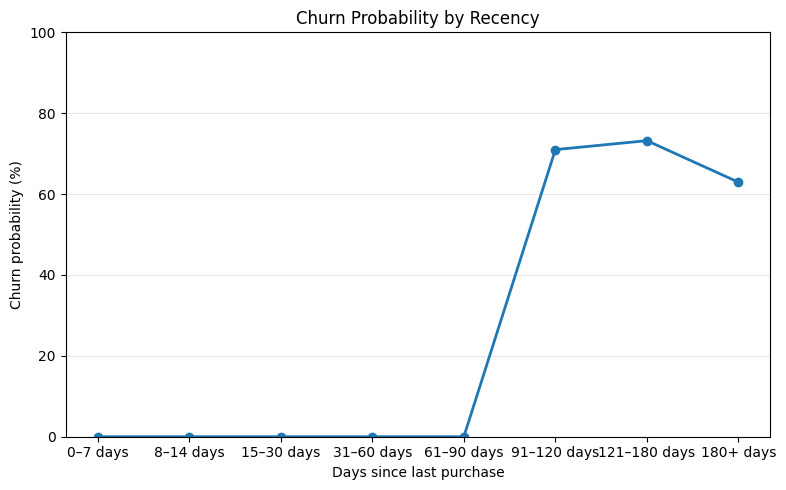

In [162]:
# Recency vs Churn plot
# Convert return rate to percentage
plot_df = recency_analysis.copy()
plot_df["churn_rate_pct"] = plot_df["churn_rate"]

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["recency_bin"].astype(str),
    plot_df["churn_rate_pct"],
    marker="o",
    linewidth=2
)

plt.xlabel("Days since last purchase")
plt.ylabel("Churn probability (%)")
plt.title("Churn Probability by Recency")
plt.ylim(0, 100)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

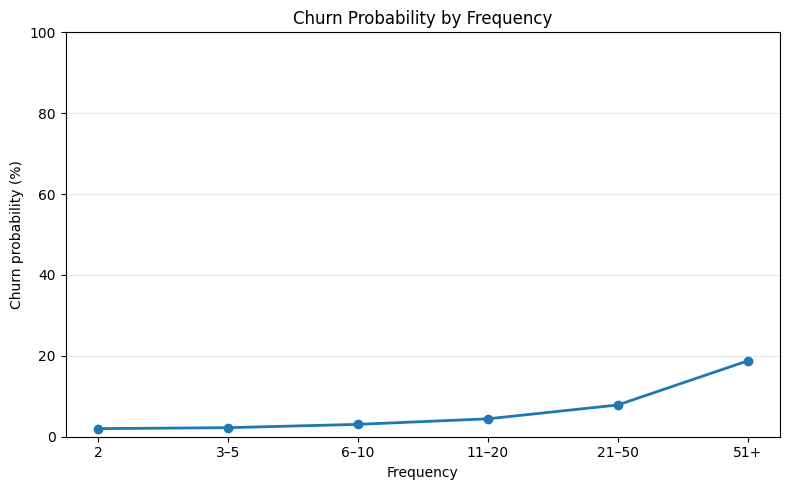

In [164]:
# Frequency vs Churn plot
# Convert return rate to percentage
plot_df_f = frequency_analysis.copy()
plot_df_f["churn_rate_pct"] = plot_df_f["churn_rate"]

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    plot_df_f["frequency_bin"].astype(str),
    plot_df_f["churn_rate_pct"],
    marker="o",
    linewidth=2
)

plt.xlabel("Frequency")
plt.ylabel("Churn probability (%)")
plt.title("Churn Probability by Frequency")
plt.ylim(0, 100)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [134]:
# Correlation analysis (Pearson + Spearman)
for var in ["frequency", "recency_days"]:
    pearson_r, pearson_p = stats.pearsonr(last_transaction[var], last_transaction['churned_90d'])
    spearman_r, spearman_p = stats.spearmanr(last_transaction[var], last_transaction['churned_90d'])
    print(f"\n{var} vs churn:")
    print(f"  Pearson  r = {pearson_r:.3f}  (p = {pearson_p:.5g})")
    print(f"  Spearman r = {spearman_r:.3f}  (p = {spearman_p:.5g})")


frequency vs churn:
  Pearson  r = -0.112  (p = 0)
  Spearman r = -0.157  (p = 0)

recency_days vs churn:
  Pearson  r = 0.844  (p = 0)
  Spearman r = 0.605  (p = 0)


# H2: 30+ day inactivity threshold
H2: Cards that go quiet for 30+ days have a materially lower probability of reactivating than cards with a shorter gap — establishing a "critical inactivity threshold" (this is the kind of number a lifecycle/marketing team would use to trigger a win-back campaign).

### Flag cards with a 30+ day gap & the Reactivated status
**Definition of Reactivated:** “Did this card make another purchase after this purchase?”
1. Create every **consecutive transaction gap** for each card_id.
2. Identify whether each gap is **completed (the next transaction is observed)** or **right-censored (the transaction is the last observed transaction for that card)**.


In [49]:
def flag_reactivate(df):
    # 1. Prepare transaction data
    df["purchase_date"] = pd.to_datetime(df["purchase_date"])

    # Sort chronologically within each card
    df = df.sort_values(
        ["card_id", "purchase_date"]
    ).reset_index(drop=True)

    # 2. Define previous and next transaction
    # previous purchase date
    df["prev_purchase_date"] = (
        df.groupby("card_id")["purchase_date"]
          .shift(1)
    )
    # next purchae date
    df["next_purchase_date"] = (
        df.groupby("card_id")["purchase_date"]
          .shift(-1)
    )
    # 3. Define the observation end date
    observation_end = df["purchase_date"].max()
    
    print("Observation end:", observation_end)

    # 4. Calculate the gap to the next transaction
    df["gap_days"] = (
        df["next_purchase_date"] - df["purchase_date"]
    ).dt.total_seconds() / (60 * 60 * 24)

    # 5. Identify completed vs right-censored episodes
    # A completed gap has a subsequent transaction
    df["completed_gap"] = df["next_purchase_date"].notna()

    # A right-censored episode is the last observed transaction
    df["right_censored"] = df["next_purchase_date"].isna()

    # 6. For censored observations, calculate observed
    #  follow-up time until the dataset ends
        # IF customer purchased again: followup_days = days until their next purchase
        # ELSE: followup_days = days from their purchase until the dataset ended
    df["followup_days"] = np.where(
        df["completed_gap"],
        df["gap_days"],
        (
            observation_end - df["purchase_date"]
        ).dt.total_seconds() / (60 * 60 * 24)
    )

    # 7. Define reactivation
    # Reactivated = a subsequent transaction was observed
    df["reactivated"] = df["completed_gap"].astype(int)

    return df

In [50]:
transactions = flag_reactivate(transactions)
transactions.head()

Observation end: 2018-04-30 23:59:59


,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,...,date,last_purchase_date,days_since_last_purchase,prev_purchase_date,next_purchase_date,gap_days,completed_gap,right_censored,followup_days,reactivated
0,Y,C_ID_00007093c1,244,N,2,C,705,M_ID_69423b34e4,-12,0.037176,...,2017-02-14,2018-04-09 16:23:59,21,NaT,2017-02-14 15:47:45,0.074329,True,False,0.074329,1
1,Y,C_ID_00007093c1,244,N,1,B,705,M_ID_a33355a1b7,-12,-0.467415,...,2017-02-14,2018-04-09 16:23:59,21,2017-02-14 14:00:43,2017-02-16 15:37:58,1.993206,True,False,1.993206,1
2,Y,C_ID_00007093c1,244,N,1,B,307,M_ID_9400cf2342,-12,-0.572600,...,2017-02-16,2018-04-09 16:23:59,21,2017-02-14 15:47:45,2017-02-20 12:19:01,3.861840,True,False,3.861840,1
3,Y,C_ID_00007093c1,244,N,3,C,705,M_ID_a33355a1b7,-12,-0.331575,...,2017-02-20,2018-04-09 16:23:59,21,2017-02-16 15:37:58,2017-03-03 00:24:15,10.503634,True,False,10.503634,1
4,Y,C_ID_00007093c1,244,N,1,B,307,M_ID_9400cf2342,-11,-0.483944,...,2017-03-03,2018-04-09 16:23:59,21,2017-02-20 12:19:01,2017-03-06 18:50:42,3.768368,True,False,3.768368,1


In [51]:
columns = ["gap_days", "completed_gap","right_censored","followup_days", "reactivated"]
transactions[columns].describe().round(2)

,gap_days,followup_days,reactivated
count,30749852.00,31075392.00,31075392.00
mean,3.12,3.68,0.99
std,8.75,12.90,0.10
min,0.00,0.00,0.00
25%,0.07,0.08,1.00
50%,0.75,0.76,1.00
75%,2.23,2.36,1.00
max,380.23,453.66,1.00


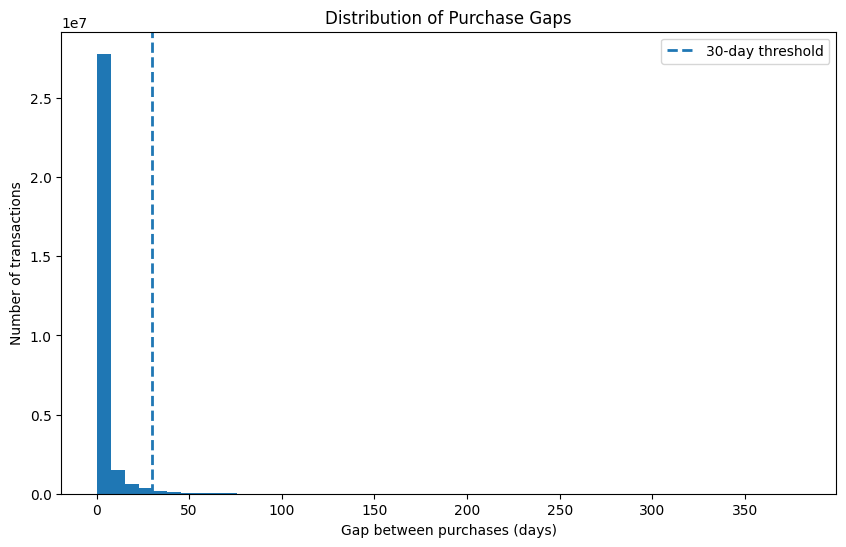

In [52]:
# plot gap_days
plt.figure(figsize=(10, 6))

plt.hist(
    transactions["gap_days"].dropna(),
    bins=50
)

plt.axvline(
    30,
    linestyle="--",
    linewidth=2,
    label="30-day threshold"
)

plt.xlabel("Gap between purchases (days)")
plt.ylabel("Number of transactions")
plt.title("Distribution of Purchase Gaps")
plt.legend()

plt.show()

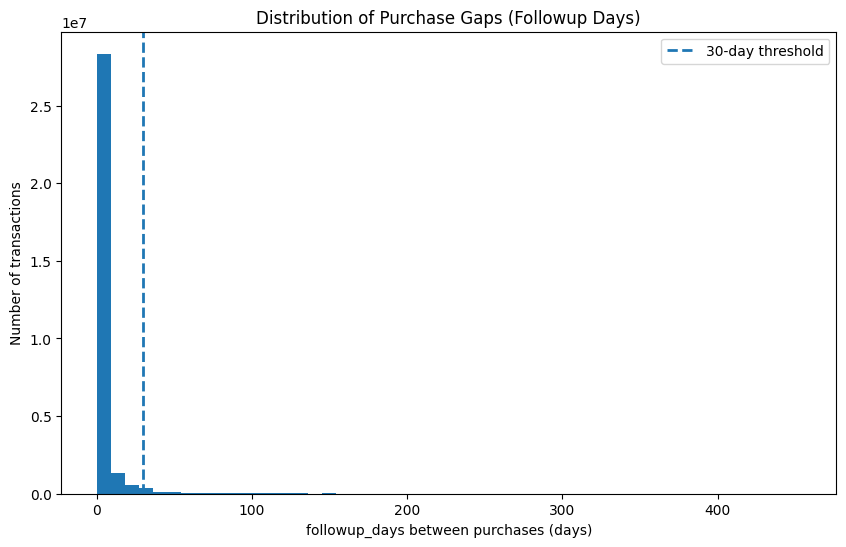

In [53]:
# Plot followup_days
plt.figure(figsize=(10, 6))

plt.hist(
    transactions["followup_days"].dropna(),
    bins=50
)

plt.axvline(
    30,
    linestyle="--",
    linewidth=2,
    label="30-day threshold"
)

plt.xlabel("followup_days between purchases (days)")
plt.ylabel("Number of transactions")
plt.title("Distribution of Purchase Gaps (Followup Days)")
plt.legend()

plt.show()

In [54]:
transactions.groupby('reactivated').followup_days.mean()

reactivated
0    57.285764
1     3.115625
Name: followup_days, dtype: float64

In [55]:
bins = [
    0,
    1,
    3,
    7,
    14,
    21,
    30,
    45,
    60,
    90,
    180,
    np.inf
]

labels = [
    "0–1",
    "1–3",
    "3–7",
    "7–14",
    "14–21",
    "21–30",
    "30–45",
    "45–60",
    "60–90",
    "90–180",
    "180+"
]

transactions["inactivity_bin"] = pd.cut(
    transactions["followup_days"],
    bins=bins,
    labels=labels,
    right=False
)

In [56]:
summary = (
    transactions
    .groupby("inactivity_bin", observed=True)
    .agg(
        n=("reactivated", "size"),
        reactivated=("reactivated", "sum"),
        reactivation_rate=("reactivated", "mean")
    )
    .reset_index()
)

summary

,inactivity_bin,n,reactivated,reactivation_rate
0,0–1,18178340,18158218,0.998893
1,1–3,6193747,6168480,0.995921
2,3–7,3277708,3243077,0.989434
3,7–14,1604065,1565958,0.976243
4,14–21,670204,643153,0.959638
5,21–30,486855,464176,0.953417
6,30–45,318586,283891,0.891097
7,45–60,123390,103702,0.840441
8,60–90,112281,73699,0.656380
9,90–180,75382,39664,0.526173


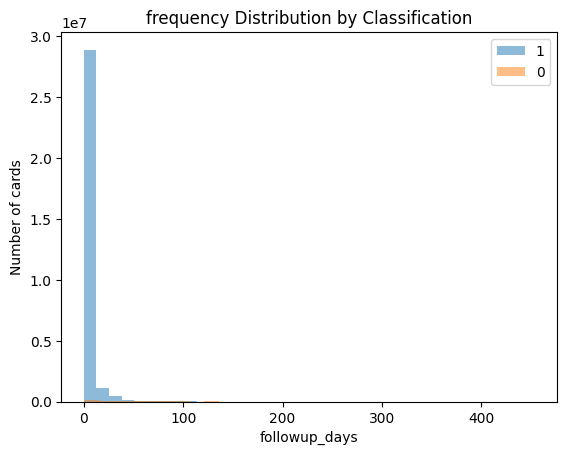

In [57]:
# Visualization
# Followup_days vs Reactivation
groups_r = transactions["reactivated"].unique()

for group in groups_r:
    plt.hist(
        transactions.loc[transactions["reactivated"] == group, "followup_days"],
        bins=30,
        alpha=0.5,
        label=group
    )

plt.xlabel("followup_days")
plt.ylabel("Number of cards")
plt.title("frequency Distribution by Classification")
plt.legend()
plt.show()

In [58]:
groups_r

array([1, 0])

In [59]:
transactions['gap_days'].describe()

count    3.074985e+07
mean     3.115625e+00
std      8.745752e+00
min      0.000000e+00
25%      7.474537e-02
50%      7.479977e-01
75%      2.231007e+00
max      3.802297e+02
Name: gap_days, dtype: float64

In [60]:
transactions["gap_days"].describe().round(0)

count    30749852.0
mean            3.0
std             9.0
min             0.0
25%             0.0
50%             1.0
75%             2.0
max           380.0
Name: gap_days, dtype: float64

In [61]:
transactions[["reactivated", "followup_days"]].isna().sum()

reactivated      0
followup_days    0
dtype: int64

In [62]:
transactions["gap_days"].unique()

array([ 0.0743287 ,  1.99320602,  3.86184028, ..., 22.45466435,
       13.37171296,  7.43166667])

In [63]:
# Drop the NaN values from "gap_days"
# Null values are there when the end date is not speified whithin the timeframe of the dataset
# Drop rows where gap_days is NaN
transactions_notna = transactions[
    transactions["gap_days"].notna()
].copy()

transactions_notna.shape

(30749852, 26)

In [64]:
transactions_notna['reactivated'].value_counts()

reactivated
1    30749852
Name: count, dtype: int64

### Survival Analysis

In [66]:
from lifelines import KaplanMeierFitter, NelsonAalenFitter

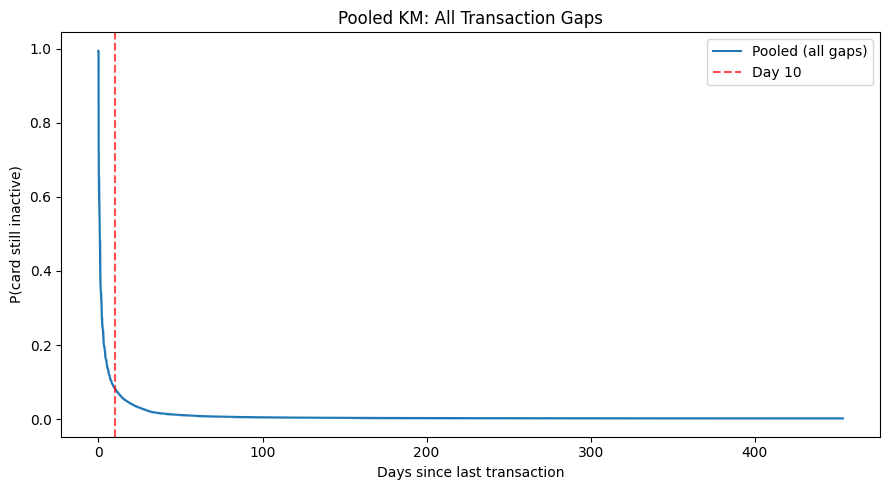

In [172]:
# POOLED KM (all gap-rows, as-is)
kmf_pooled = KaplanMeierFitter()
kmf_pooled.fit(
    durations=transactions["followup_days"],
    event_observed=transactions["reactivated"],
    label="Pooled (all gaps)"
)
 
plt.figure(figsize=(9, 5))
kmf_pooled.plot_survival_function(ci_show=True)
plt.axvline(10, color="red", linestyle="--", alpha=0.7, label="Day 10")
plt.xlabel("Days since last transaction")
plt.ylabel("P(card still inactive)")
plt.title("Pooled KM: All Transaction Gaps")
plt.legend()
plt.tight_layout()
plt.savefig("km_pooled.png", dpi=150)
plt.show()

**Landmark/conditional survival:** among cards that have already survived to day 30 (i.e., are already "quiet" at that point), 
plot their subsequent reactivation curve, and compare it to the reactivation curve for cards conditioned on surviving to, say, day 5 or day 10. If day-30 survivors reactivate much slower than day-5 survivors, that's real evidence for a threshold.
- **Question:** given a card is still inactive 10 days after its last transaction, how much longer until it reactivates?

In [201]:
# Dataset for 10 days inactive
landmark_time_10 = 10

# 1. Select gaps that survived to the landmark
mask_10 = transactions['followup_days']  >= landmark_time_10   # true whether event or censored

landmark_df_10 = transactions[mask].copy()

# 2. Re-baseline: time since the landmark, not since original transaction
landmark_df_10['t_since_landmark'] = landmark_df_10['followup_days'] - landmark_time_10

# 3. event_observed stays as-is (True if it reactivated, False/censored if still open)

In [230]:
landmark_df_10[['t_since_landmark','reactivated']].describe().round(2)

,t_since_landmark,reactivated
count,2520007.00,2520007.00
mean,20.06,0.91
std,35.37,0.29
min,0.00,0.00
25%,3.63,1.00
50%,9.68,1.00
75%,20.79,1.00
max,443.66,1.00


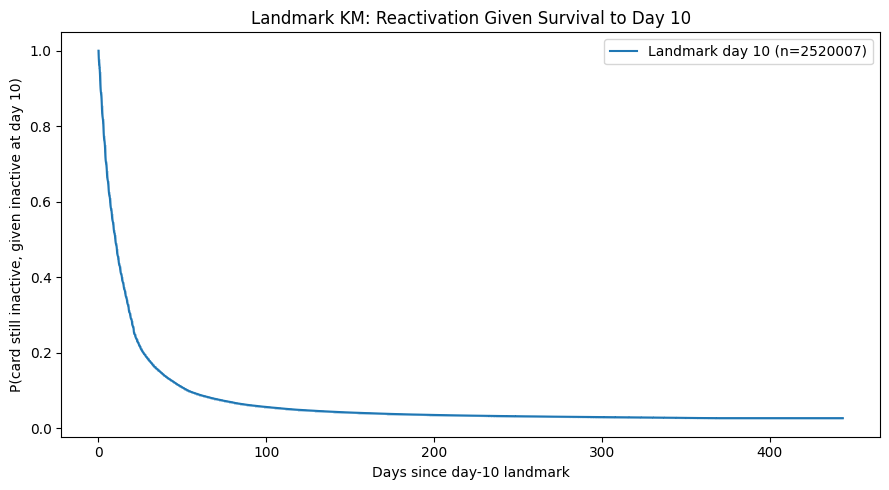

In [205]:
# LANDMARK KM: cards that survived to day 10, curve re-baselined to t=0 at day 10
kmf_landmark10 = KaplanMeierFitter()
kmf_landmark10.fit(
    durations=landmark_df_10["t_since_landmark"],   # <- re-baselined, not followup_days
    event_observed=landmark_df_10["reactivated"],
    label="Landmark day 10 (n={})".format(len(landmark_df_10))
)

plt.figure(figsize=(9, 5))
kmf_landmark10.plot_survival_function(ci_show=True)
plt.xlabel("Days since day-10 landmark")
plt.ylabel("P(card still inactive, given inactive at day 10)")
plt.title("Landmark KM: Reactivation Given Survival to Day 10")
plt.legend()
plt.tight_layout()
plt.savefig("km_landmark10.png", dpi=150)
plt.show()

In [218]:
# Dataset for 5 days inactive
landmark_time_5 = 5

# 1. Select gaps that survived to the landmark
mask_5 = transactions['followup_days']  >= landmark_time_5   # true whether event or censored

landmark_df_5 = transactions[mask_5].copy()

# 2. Re-baseline: time since the landmark, not since original transaction
landmark_df_5['t_since_landmark'] = landmark_df_5['followup_days'] - landmark_time_5

# 3. event_observed stays as-is (True if it reactivated, False/censored if still open)

In [228]:
landmark_df_5[['t_since_landmark','reactivated']].describe().round(2)

,t_since_landmark,reactivated
count,4583141.00,4583141.00
mean,14.67,0.94
std,28.64,0.23
min,0.00,0.00
25%,1.99,1.00
50%,6.08,1.00
75%,16.04,1.00
max,448.66,1.00


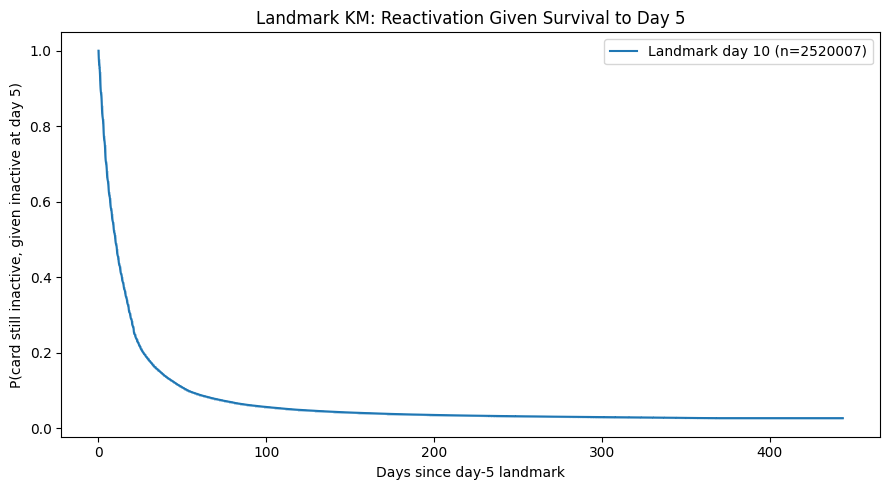

In [212]:
# LANDMARK KM: cards that survived to day 10, curve re-baselined to t=0 at day 10
kmf_landmark5 = KaplanMeierFitter()
kmf_landmark5.fit(
    durations=landmark_df_5["t_since_landmark"],   # <- re-baselined, not followup_days
    event_observed=landmark_df_5["reactivated"],
    label="Landmark day 5 (n={})".format(len(landmark_df_5))
)

plt.figure(figsize=(9, 5))
kmf_landmark10.plot_survival_function(ci_show=True)
plt.xlabel("Days since day-5 landmark")
plt.ylabel("P(card still inactive, given inactive at day 5)")
plt.title("Landmark KM: Reactivation Given Survival to Day 5")
plt.legend()
plt.tight_layout()
plt.savefig("km_landmark5.png", dpi=150)
plt.show()

In [222]:
# Dataset for 30 days inactive
landmark_time_30 = 30

# 1. Select gaps that survived to the landmark
mask_30 = transactions['followup_days']  >= landmark_time_30   # true whether event or censored

landmark_df_30 = transactions[mask_30].copy()

# 2. Re-baseline: time since the landmark, not since original transaction
landmark_df_30['t_since_landmark'] = landmark_df_30['followup_days'] - landmark_time_30

# 3. event_observed stays as-is (True if it reactivated, False/censored if still open)

In [226]:
landmark_df_30[['t_since_landmark','reactivated']].describe().round(2)

,t_since_landmark,reactivated
count,664473.00,664473.00
mean,35.78,0.76
std,54.07,0.43
min,0.00,0.00
25%,4.90,1.00
50%,16.26,1.00
75%,39.57,1.00
max,423.66,1.00


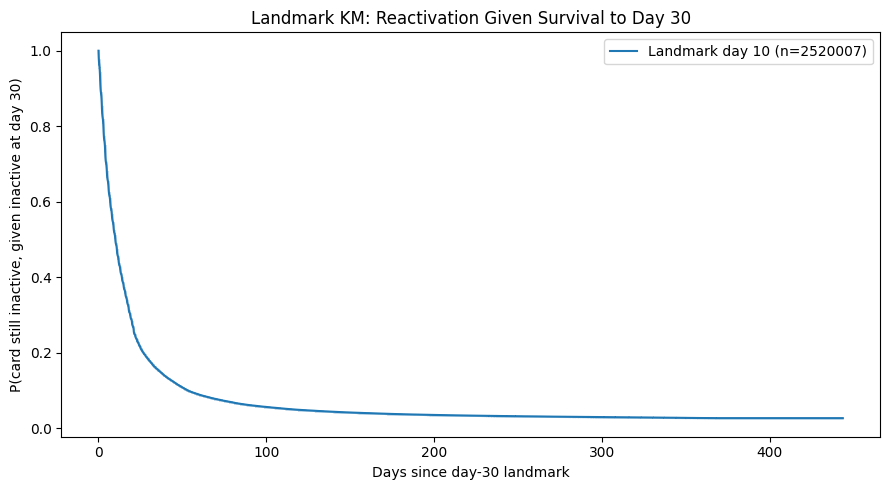

In [237]:
# LANDMARK KM: cards that survived to day 10, curve re-baselined to t=0 at day 10
kmf_landmark30 = KaplanMeierFitter()
kmf_landmark30.fit(
    durations=landmark_df_30["t_since_landmark"],   # <- re-baselined, not followup_days
    event_observed=landmark_df_30["reactivated"],
    label="Landmark day 30 (n={})".format(len(landmark_df_30))
)

plt.figure(figsize=(9, 5))
kmf_landmark10.plot_survival_function(ci_show=True)
plt.xlabel("Days since day-30 landmark")
plt.ylabel("P(card still inactive, given inactive at day 30)")
plt.title("Landmark KM: Reactivation Given Survival to Day 30")
plt.legend()
plt.tight_layout()
plt.savefig("km_landmark5.png", dpi=150)
plt.show()

### Logrank test
-> checking whether cards that were already quiet for 30 days come back at a different pace than cards that were only quiet for 5 days, once you start the clock at each group's own landmark.

In [239]:
from lifelines.statistics import logrank_test

results = logrank_test(
    landmark_df_5['t_since_landmark'], landmark_df_30['t_since_landmark'],
    event_observed_A=landmark_df_5['reactivated'], event_observed_B=landmark_df_30['reactivated']
)
results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
      255113.61 <0.005       inf